# Vision Tracker Evaluation — Plots from cached .txt files

Loads pre-computed inference `.txt` files instead of re-running inference.

**Model:** `rtdetr_fish_improved_f`
**Class:** fish (class_id = 1)
**Trackers:** ByteTrack, BOT-SORT

Run from `tracking/` directory.

In [1]:
print("Jupyter OK!")

Jupyter OK!


In [2]:
import sys
sys.path.insert(0, "..")

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from tracking.utils.mot_metrics import (
    load_gt, img_dir_for, frame_map, collect_images,
    compute_metrics, compute_hota, build_summary_table,
    plot_metrics_bar, plot_error_breakdown,
    plot_track_comparison, plot_det_timeline, plot_id_switches,
    _iou_matrix_xywh,
)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.spines.top": True, "axes.spines.right": True})


def clean_fig(fig):
    """Remove all titles; keep axis box intact."""
    fig.suptitle("")
    for ax in fig.axes:
        ax.set_title("")
    return fig


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/cluster/home/henrban/aquaculture-percepti

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
REPO        = Path("..").resolve()
VISION_ROOT = REPO / "data-processing" / "vision" / "MOT"

SELECTED_SEQUENCES = [
    "2024-08-20_14-31-29",
    "2024-08-20_17-34-52",
    "2024-08-20_17-39-32",
    "2024-08-20_17-40-54",
    "2024-08-20_17-55-40",
]

IOU_MATCH      = 0.5
TRACKERS       = ["bytetrack", "botsort"]
MODEL_NAME     = "rtdetr_fish_improved_f"
MOT_OUTPUT_DIR = Path("outputs/inference_annotation_MOT11")

all_seqs  = sorted([p.name for p in VISION_ROOT.iterdir() if p.is_dir()])
SEQUENCES = [s for s in all_seqs if s in SELECTED_SEQUENCES] if SELECTED_SEQUENCES else all_seqs

print(f"Model name : {MODEL_NAME}")
print(f"Trackers   : {TRACKERS}")
print(f"Sequences ({len(SEQUENCES)}):")
for s in SEQUENCES:
    print(f"  {s}")

Model name : rtdetr_fish_improved_f
Trackers   : ['bytetrack', 'botsort']
Sequences (5):
  2024-08-20_14-31-29
  2024-08-20_17-34-52
  2024-08-20_17-39-32
  2024-08-20_17-40-54
  2024-08-20_17-55-40


## 1  Load GT + cached inference

In [4]:
def load_mot_txt(txt_path, img_dir):
    """Load a MOT11-format inference .txt and map frame_id -> frame_norm."""
    cols = ["frame_id", "track_id", "x", "y", "w", "h",
            "not_ignored", "class_id", "visibility"]
    df = pd.read_csv(txt_path, header=None, names=cols)
    ts_fn = frame_map(img_dir)
    df["frame_id"]   = df["frame_id"].astype(np.int64)
    df["frame_norm"] = df["frame_id"].map(ts_fn)
    df = df.dropna(subset=["frame_norm"]).copy()
    df["frame_norm"] = df["frame_norm"].astype(int)
    return df.reset_index(drop=True)

# ── Load GT (class 1 = fish) ──────────────────────────────────────────────────
gt_dfs       = {}
total_frames = {}

for seq in SEQUENCES:
    seq_path          = VISION_ROOT / seq
    idir              = img_dir_for(seq_path, "vision")
    gt_dfs[seq]       = load_gt(seq_path / "gt" / "gt.txt", idir, class_id=1)
    total_frames[seq] = len(list(idir.glob("*.jpg")))

# ── Load predictions from cached .txt files ───────────────────────────────────
pred_by_tracker = {}
for tracker in TRACKERS:
    pred_by_tracker[tracker] = {}
    for seq in SEQUENCES:
        idir     = img_dir_for(VISION_ROOT / seq, "vision")
        txt_name = f"INFERENCE_MOT11_{seq}_{MODEL_NAME}+{tracker}.txt"
        txt_path = MOT_OUTPUT_DIR / txt_name
        pred_all  = load_mot_txt(txt_path, idir)
        pred_fish = pred_all[pred_all["class_id"] == 1].copy()
        pred_by_tracker[tracker][seq] = pred_fish
        print(f"  {tracker} / {seq[-8:]}: GT={len(gt_dfs[seq])}  Pred={len(pred_fish)}")

  bytetrack / 14-31-29: GT=4967  Pred=4549
  bytetrack / 17-34-52: GT=1783  Pred=1599
  bytetrack / 17-39-32: GT=500  Pred=481
  bytetrack / 17-40-54: GT=1595  Pred=1407
  bytetrack / 17-55-40: GT=1667  Pred=1453
  botsort / 14-31-29: GT=4967  Pred=4569
  botsort / 17-34-52: GT=1783  Pred=1605
  botsort / 17-39-32: GT=500  Pred=485
  botsort / 17-40-54: GT=1595  Pred=1413
  botsort / 17-55-40: GT=1667  Pred=1459


## 2  Compute metrics

In [5]:
accs_by_tracker    = {}
results_by_tracker = {}

for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    accs    = {}
    results = {}
    for seq in SEQUENCES:
        acc, summary = compute_metrics(gt_dfs[seq], pred_by_tracker[tracker][seq],
                                       iou_threshold=IOU_MATCH)
        hota = compute_hota(gt_dfs[seq], pred_by_tracker[tracker][seq])
        for k, v in hota.items():
            summary[k] = v
        accs[seq]    = acc
        results[seq] = summary
    accs_by_tracker[tracker]    = accs
    results_by_tracker[tracker] = results

    print(f"\n── {tracker.upper()} — Vision fish metrics ──")
    for seq in SEQUENCES:
        h = results[seq]
        print(f"  {seq[-8:]}  "
              f"HOTA={float(h['hota'].iloc[0])*100:.1f}%  "
              f"MOTA={float(h['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(h['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(h['num_switches'].iloc[0])}")
    display(build_summary_table(results))


── BYTETRACK — Vision fish metrics ──
  14-31-29  HOTA=81.2%  MOTA=89.1%  IDF1=87.9%  IDSW=22
  17-34-52  HOTA=76.8%  MOTA=80.7%  IDF1=76.9%  IDSW=42
  17-39-32  HOTA=87.5%  MOTA=89.4%  IDF1=90.5%  IDSW=2
  17-40-54  HOTA=88.0%  MOTA=84.5%  IDF1=89.4%  IDSW=17
  17-55-40  HOTA=75.8%  MOTA=77.0%  IDF1=82.0%  IDSW=30


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,81.2%,77.3%,89.1%,89.1%,87.9%,6.7%,90.6%,98.9%,51,469,22,42,0,53
1,17-34-52,76.8%,76.5%,77.5%,80.7%,76.9%,4.1%,86.4%,96.3%,59,243,42,42,1,63
2,17-39-32,87.5%,82.6%,94.2%,89.4%,90.5%,4.6%,93.0%,96.7%,16,35,2,21,0,24
3,17-40-54,88.0%,82.3%,94.2%,84.5%,89.4%,2.2%,86.9%,98.5%,21,209,17,41,4,60
4,17-55-40,75.8%,68.5%,86.5%,77.0%,82.0%,7.6%,83.0%,95.2%,70,284,30,41,3,65



── BOTSORT — Vision fish metrics ──
  14-31-29  HOTA=83.0%  MOTA=89.7%  IDF1=89.2%  IDSW=12
  17-34-52  HOTA=80.2%  MOTA=80.6%  IDF1=83.5%  IDSW=34
  17-39-32  HOTA=89.9%  MOTA=90.4%  IDF1=94.8%  IDSW=1
  17-40-54  HOTA=89.1%  MOTA=85.3%  IDF1=90.8%  IDSW=13
  17-55-40  HOTA=76.5%  MOTA=79.3%  IDF1=82.8%  IDSW=15


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,83.0%,77.6%,92.8%,89.7%,89.2%,6.6%,91.0%,98.9%,51,449,12,42,0,53
1,17-34-52,80.2%,76.4%,84.6%,80.6%,83.5%,4.6%,86.3%,95.8%,67,245,34,43,1,63
2,17-39-32,89.9%,82.9%,99.2%,90.4%,94.8%,4.7%,93.8%,96.7%,16,31,1,22,0,24
3,17-40-54,89.1%,82.5%,96.4%,85.3%,90.8%,2.3%,87.3%,98.6%,20,202,13,42,4,60
4,17-55-40,76.5%,69.2%,87.2%,79.3%,82.8%,7.5%,83.9%,95.8%,61,269,15,42,2,65


## 3  Metrics bar charts

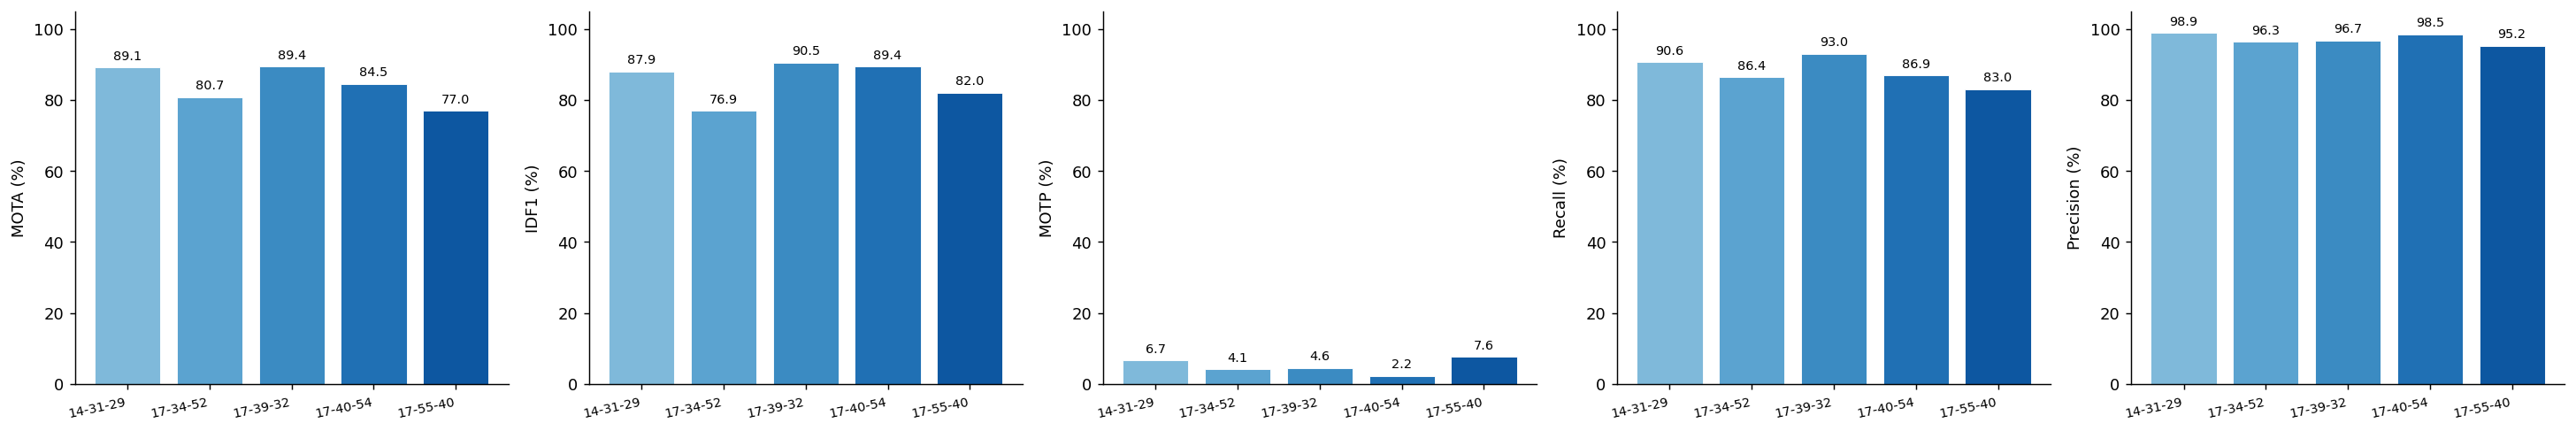

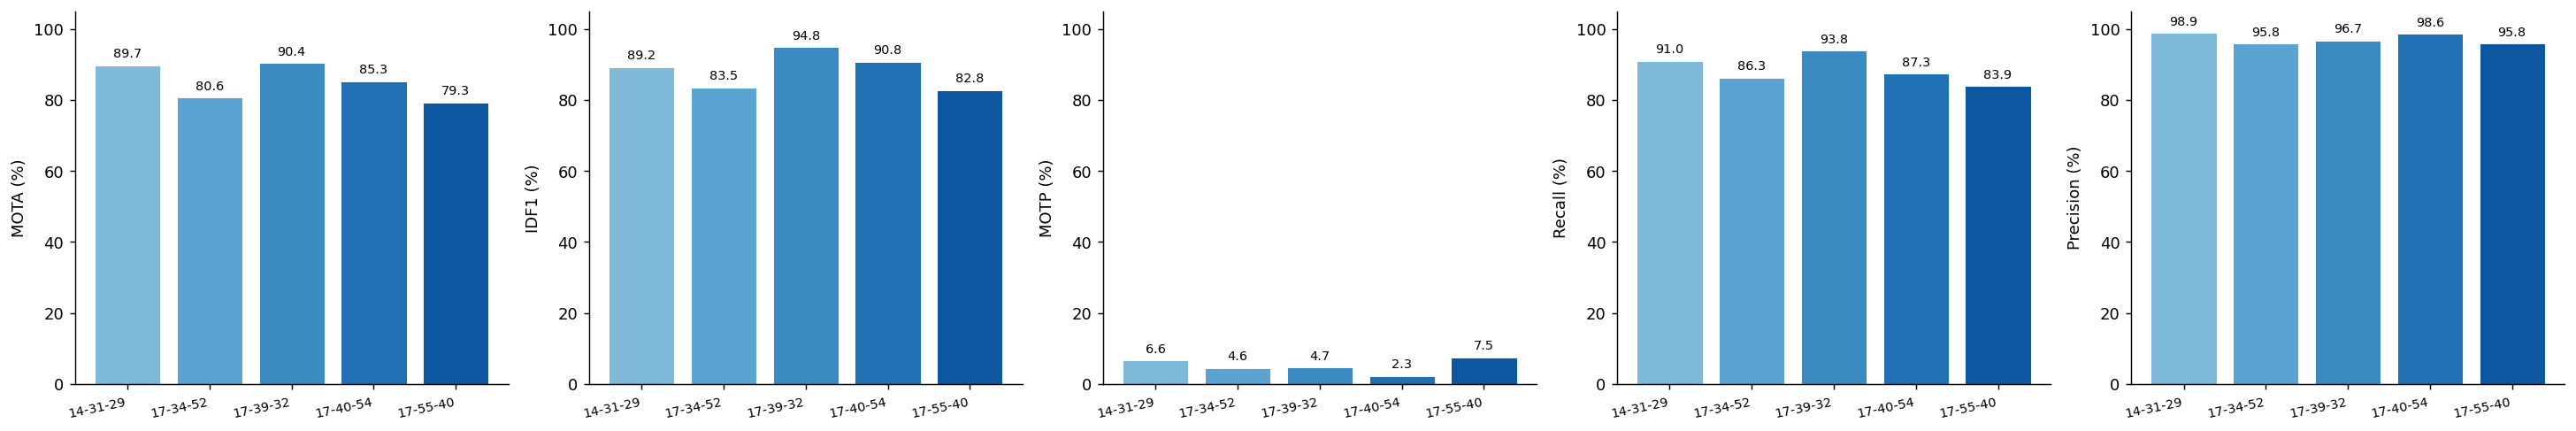

In [6]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_metrics_bar(results_by_tracker[tracker],
                           metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                           title="")
    clean_fig(fig)
    plt.tight_layout()
    plt.savefig(f"outputs/vision_{run_tag}_metrics_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4  Error breakdown — FP / FN / ID switches

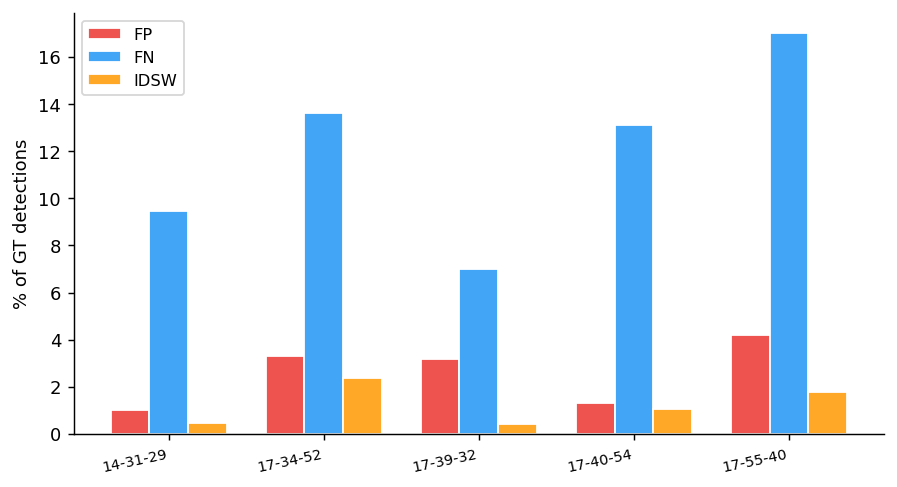

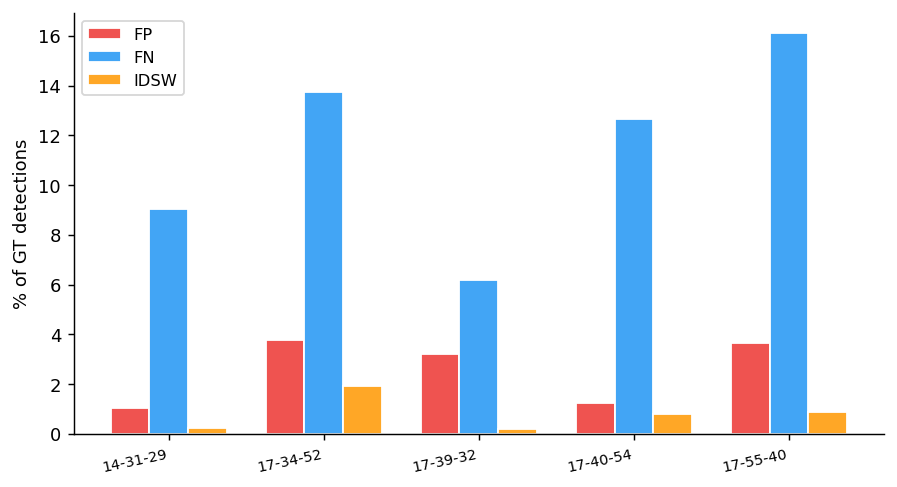

In [7]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_error_breakdown(results_by_tracker[tracker], title="")
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

## 5  GT vs predicted track count

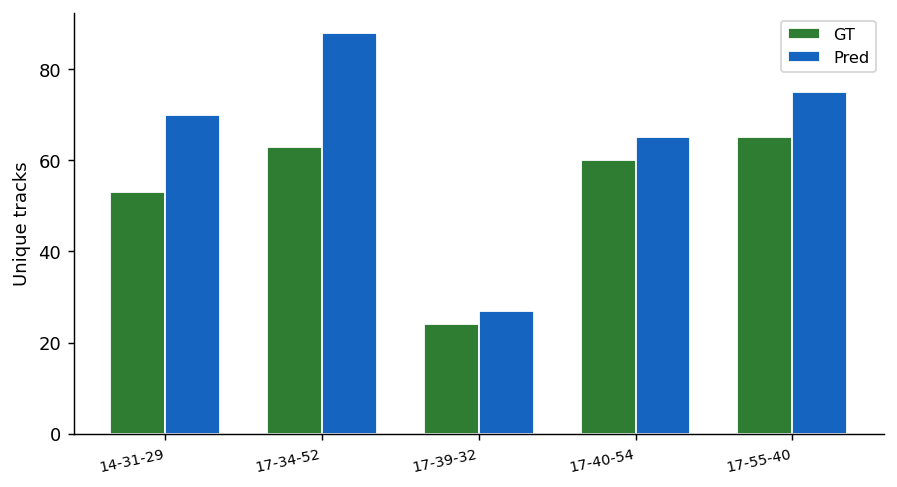

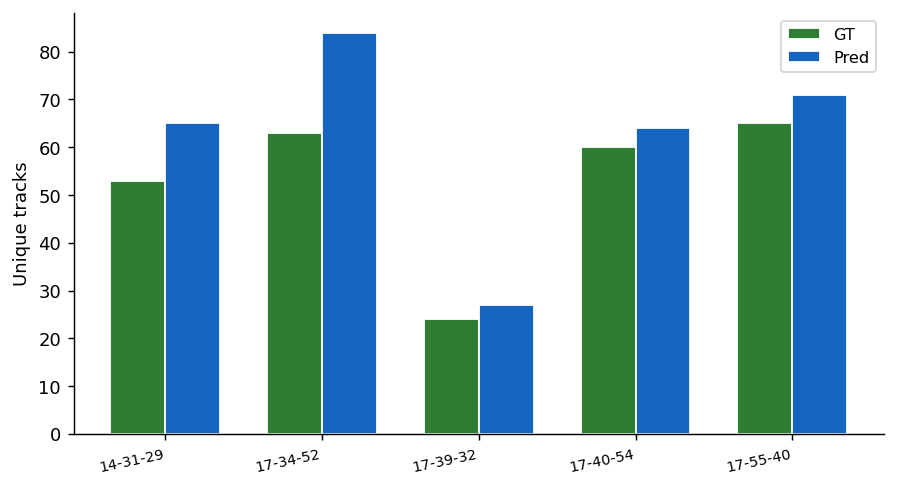

In [8]:
for tracker in TRACKERS:
    fig = plot_track_comparison(gt_dfs, pred_by_tracker[tracker])
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

## 6  Detection count per frame — GT vs predicted

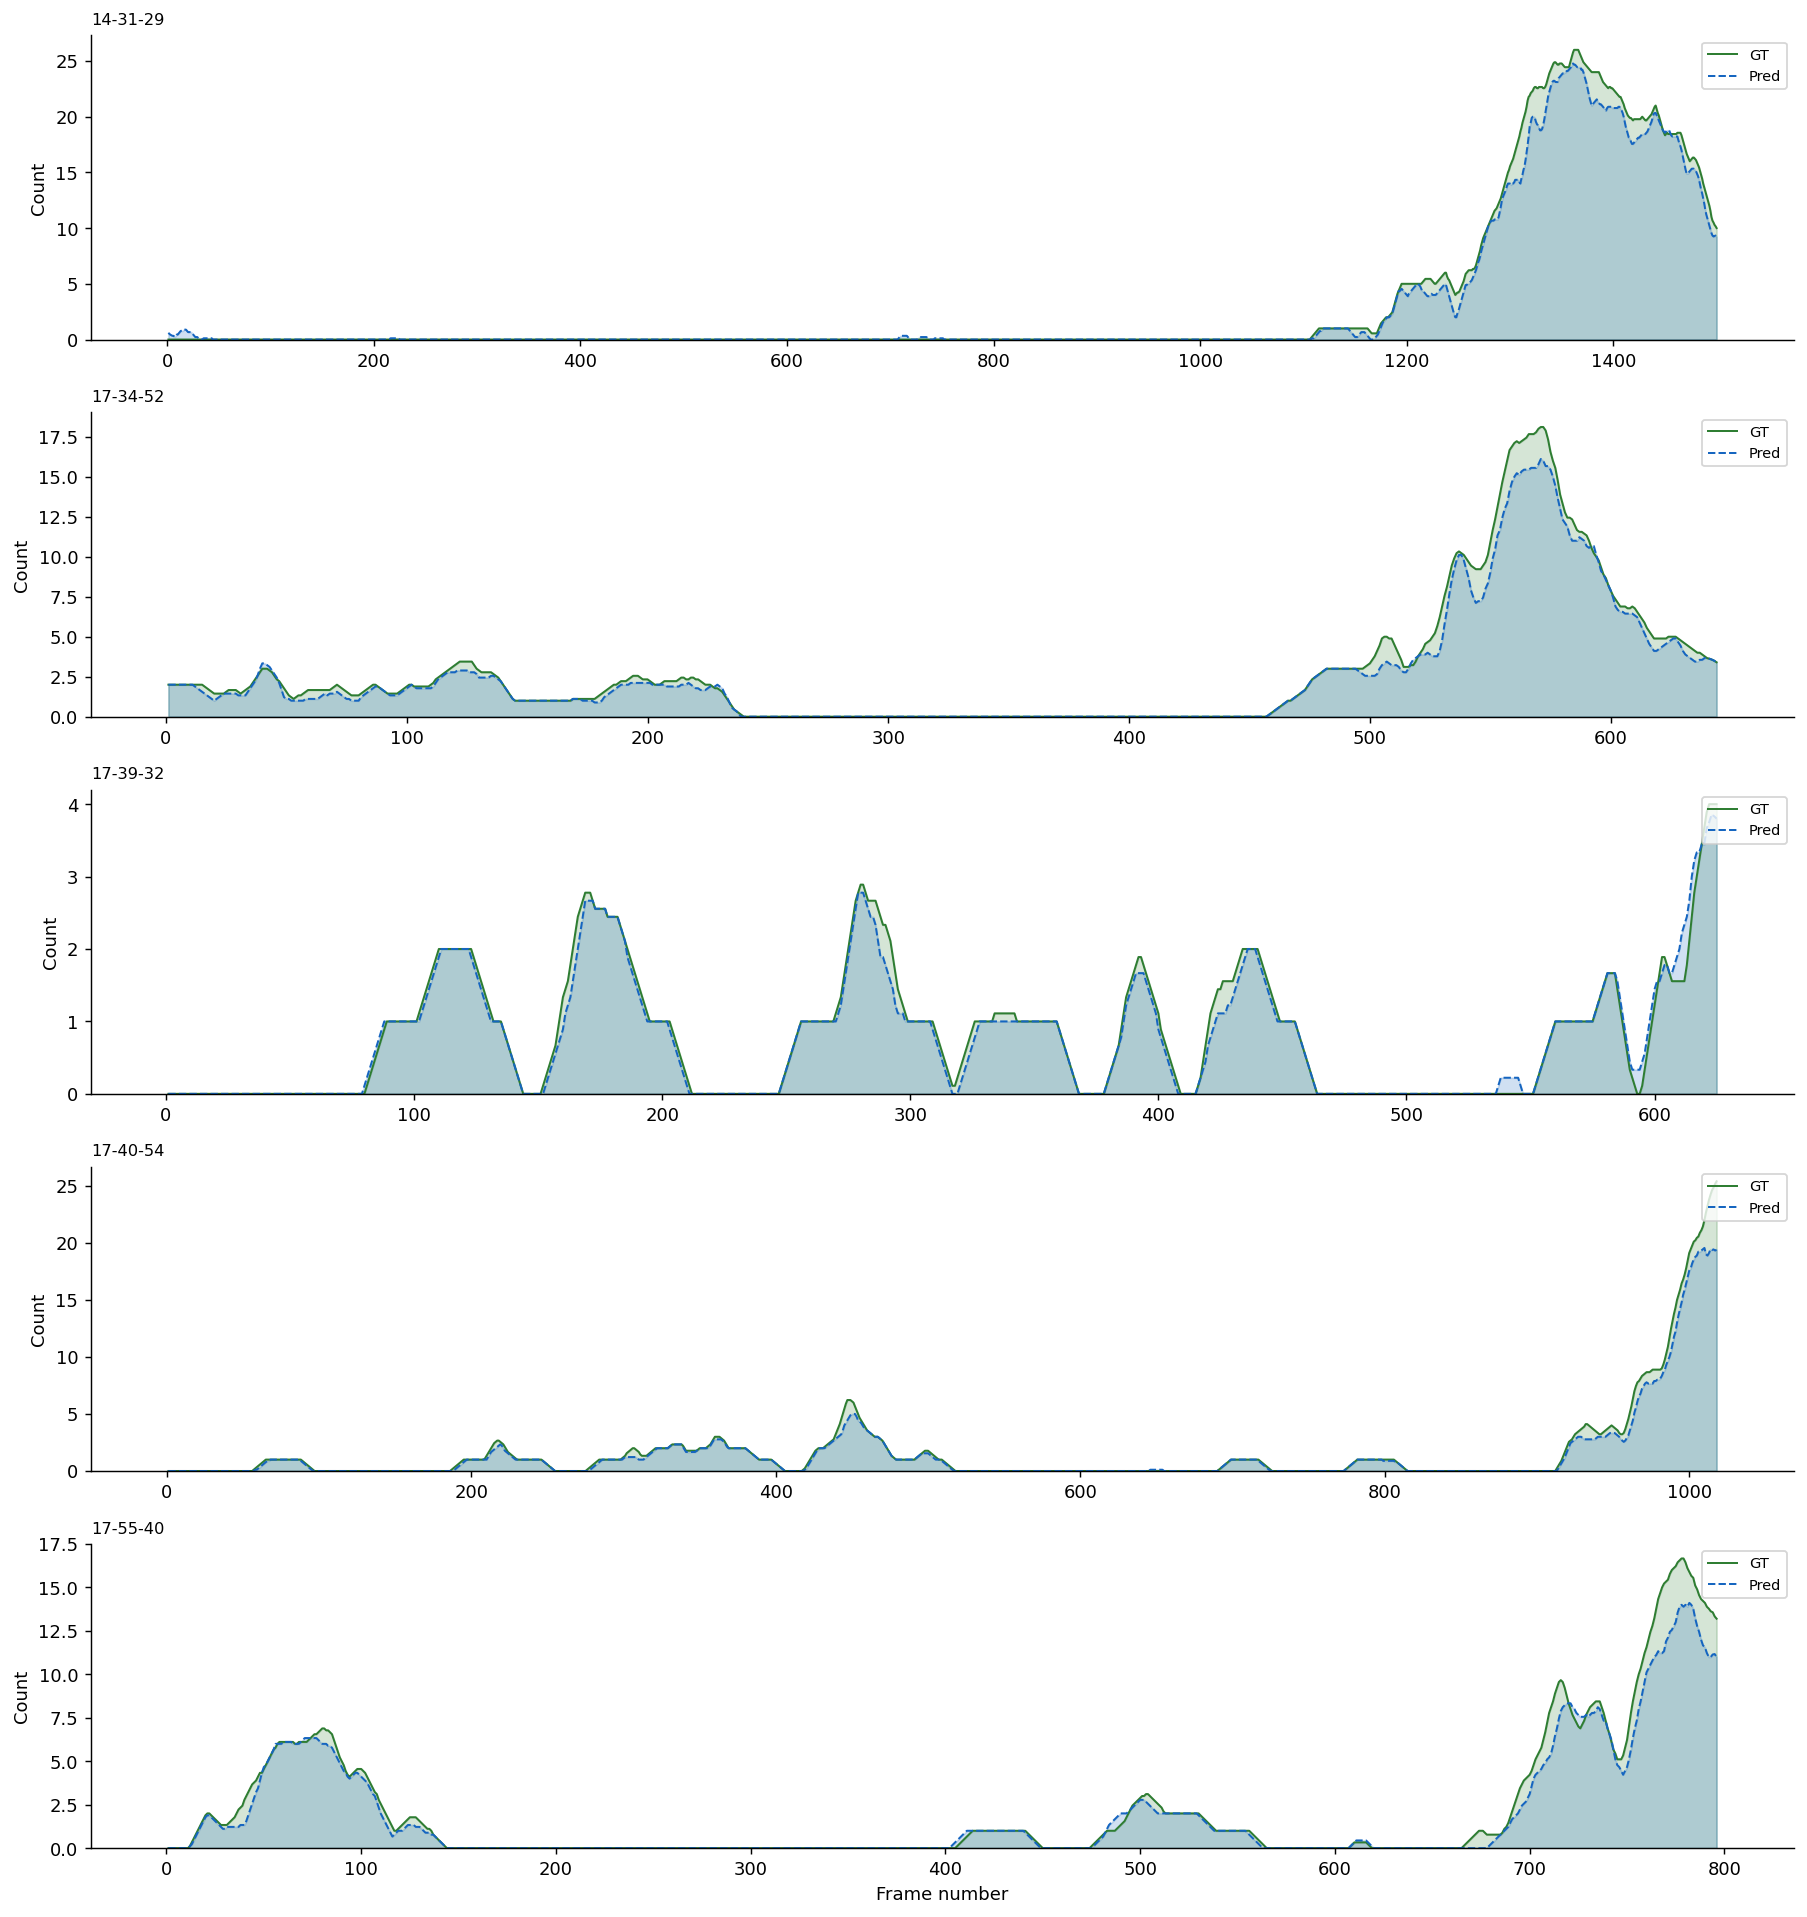

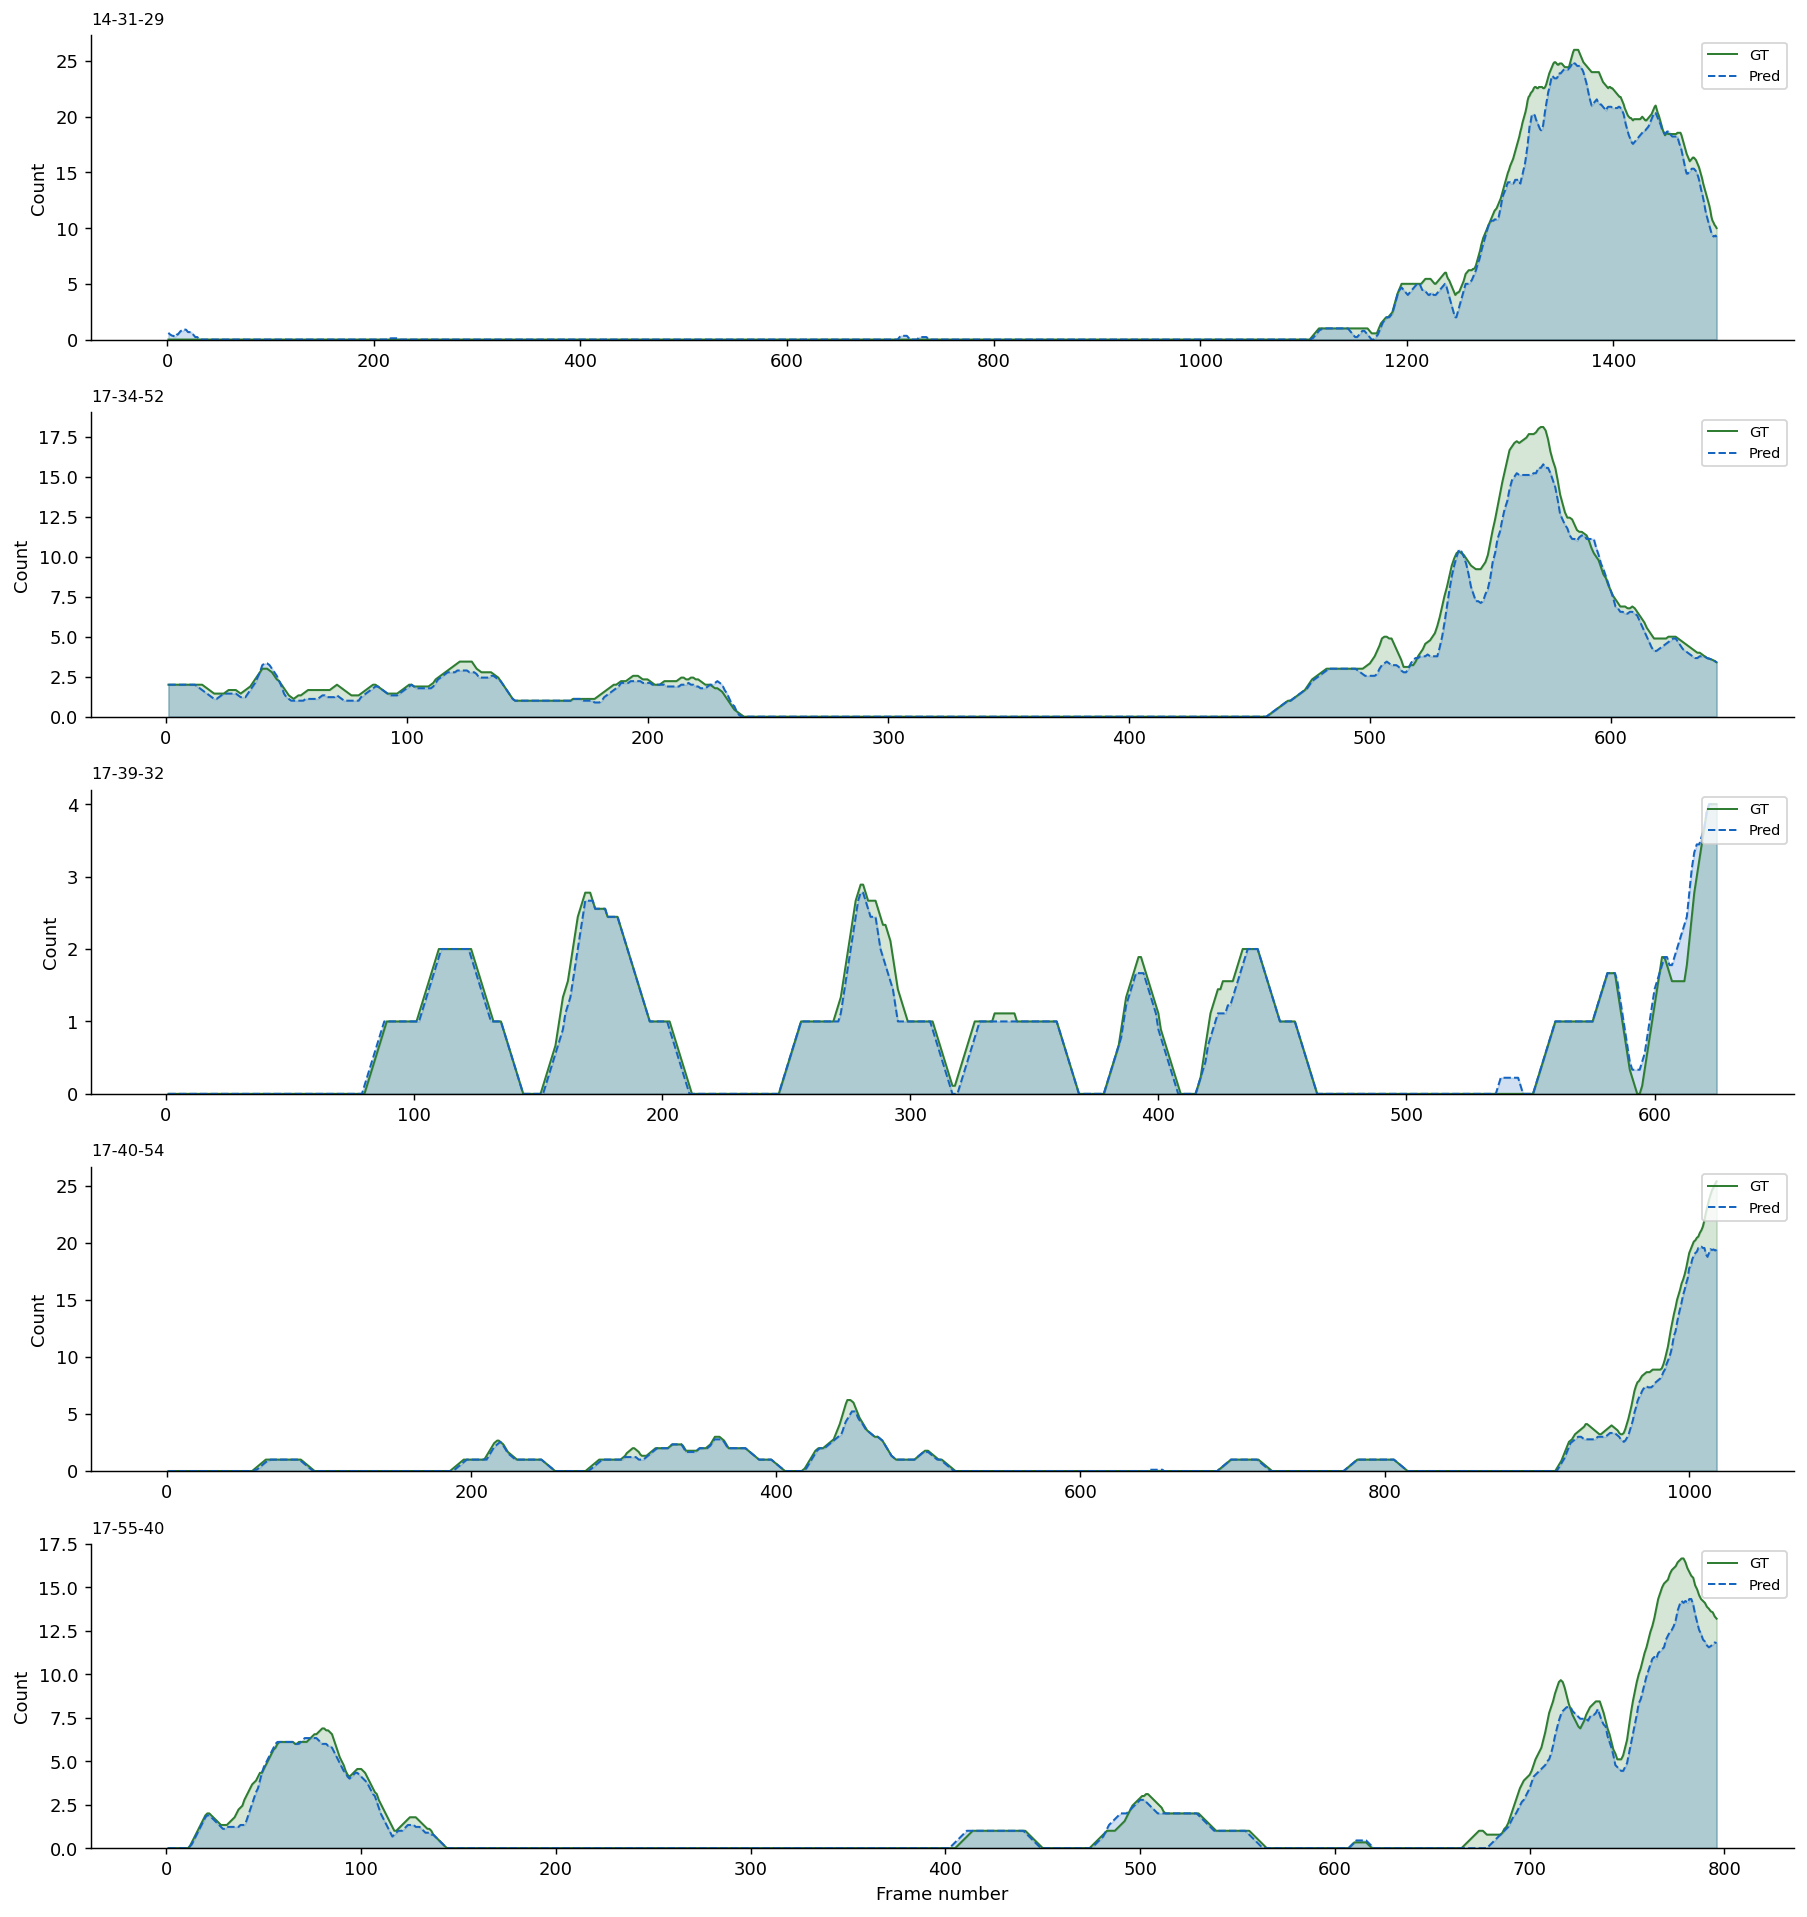

In [9]:
for tracker in TRACKERS:
    fig = plot_det_timeline(gt_dfs, pred_by_tracker[tracker], total_frames, title="")
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

## 7  Cumulative ID switches over time

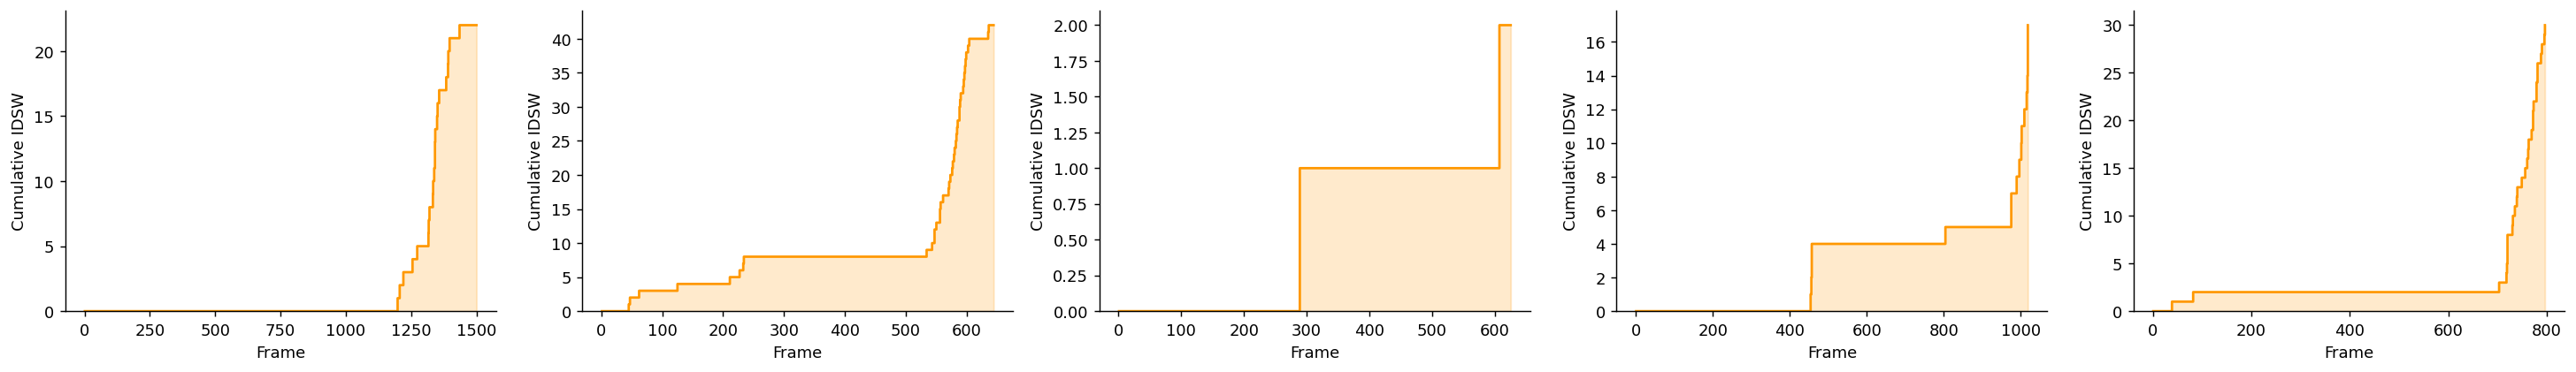

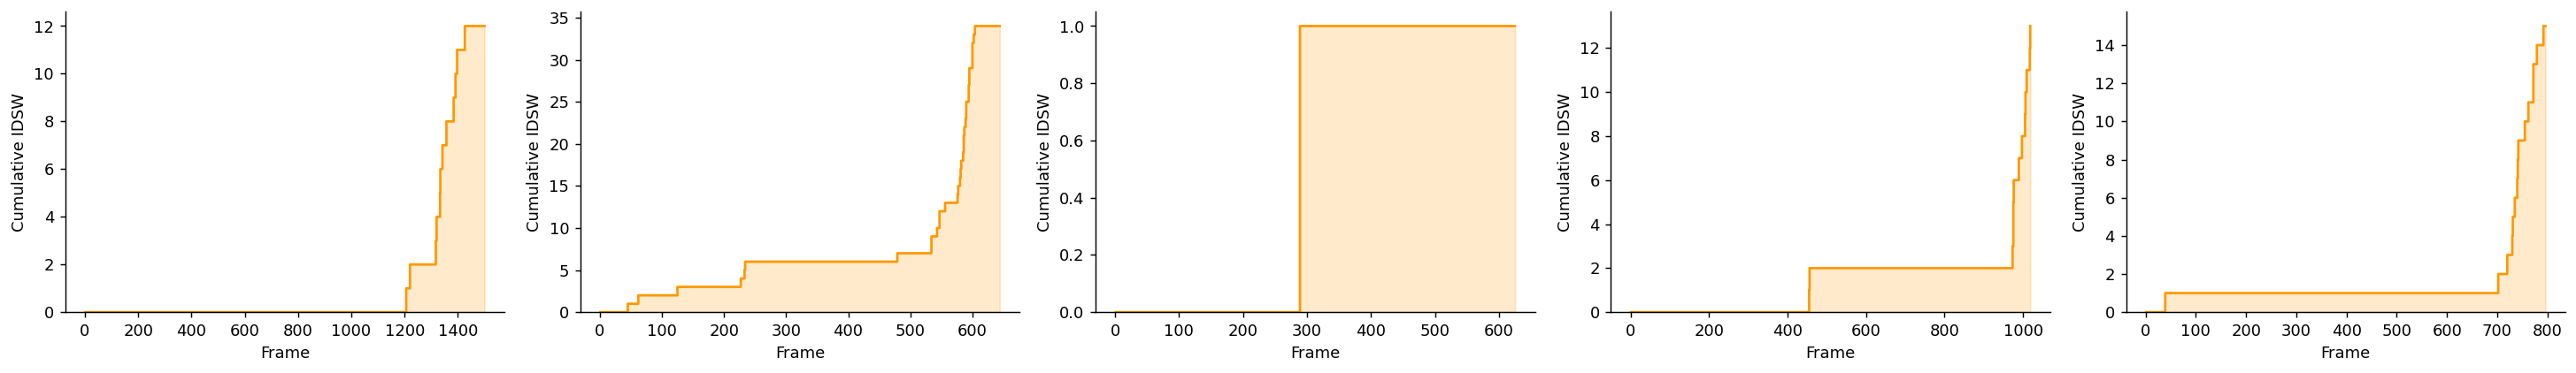

In [10]:
for tracker in TRACKERS:
    fig = plot_id_switches(accs_by_tracker[tracker], total_frames, title="")
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

## 8  MT / PT / ML breakdown

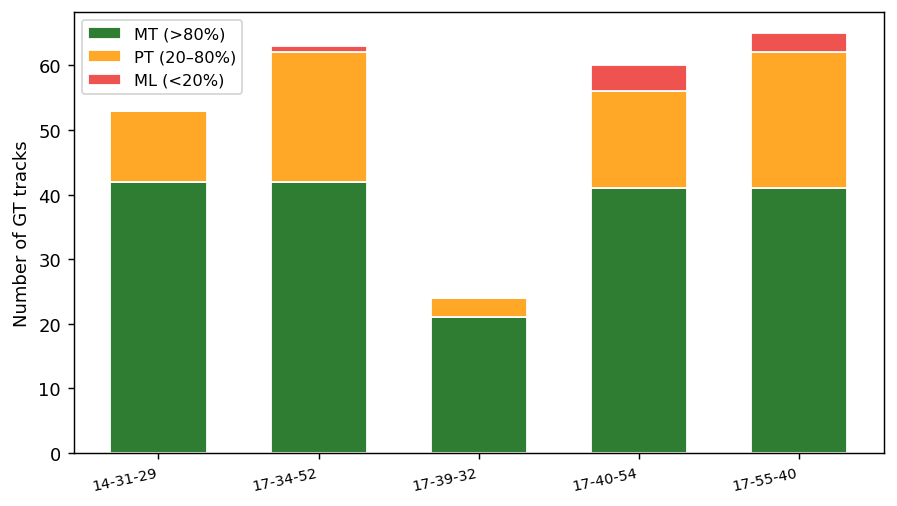

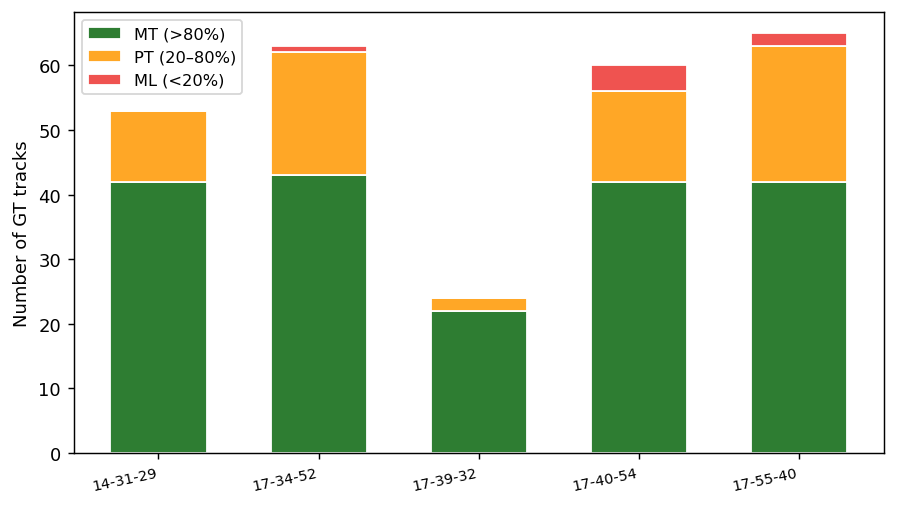

In [11]:
for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    results   = results_by_tracker[tracker]
    seq_names = list(results.keys())
    mt_vals   = [int(results[s]["mostly_tracked"].iloc[0])    for s in seq_names]
    pt_vals   = [int(results[s]["partially_tracked"].iloc[0]) for s in seq_names]
    ml_vals   = [int(results[s]["mostly_lost"].iloc[0])       for s in seq_names]

    x = np.arange(len(seq_names))
    fig, ax = plt.subplots(figsize=(7, 4))
    w = 0.6
    ax.bar(x, mt_vals, width=w, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
    ax.bar(x, pt_vals, width=w, bottom=mt_vals, label="PT (20–80%)", color="#FFA726", edgecolor="white")
    ax.bar(x, ml_vals, width=w, bottom=[m+p for m,p in zip(mt_vals,pt_vals)],
           label="ML (<20%)", color="#EF5350", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([s[-8:] for s in seq_names], rotation=12, ha="right", fontsize=8)
    ax.set_ylabel("Number of GT tracks")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 9  Combined — all sequences
Aggregates all sequences into a single evaluation per tracker.


── BYTETRACK combined (5 seq) ──
HOTA=81.0%  MOTA=85.1%  IDF1=85.5%  IDSW=113


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,81.2%,77.3%,89.1%,89.1%,87.9%,6.7%,90.6%,98.9%,51,469,22,42,0,53
1,17-34-52,76.8%,76.5%,77.5%,80.7%,76.9%,4.1%,86.4%,96.3%,59,243,42,42,1,63
2,17-39-32,87.5%,82.6%,94.2%,89.4%,90.5%,4.6%,93.0%,96.7%,16,35,2,21,0,24
3,17-40-54,88.0%,82.3%,94.2%,84.5%,89.4%,2.2%,86.9%,98.5%,21,209,17,41,4,60
4,17-55-40,75.8%,68.5%,86.5%,77.0%,82.0%,7.6%,83.0%,95.2%,70,284,30,41,3,65
5,COMBINED,81.0%,76.4%,87.8%,85.1%,85.5%,5.6%,88.2%,97.7%,217,1240,113,187,8,265


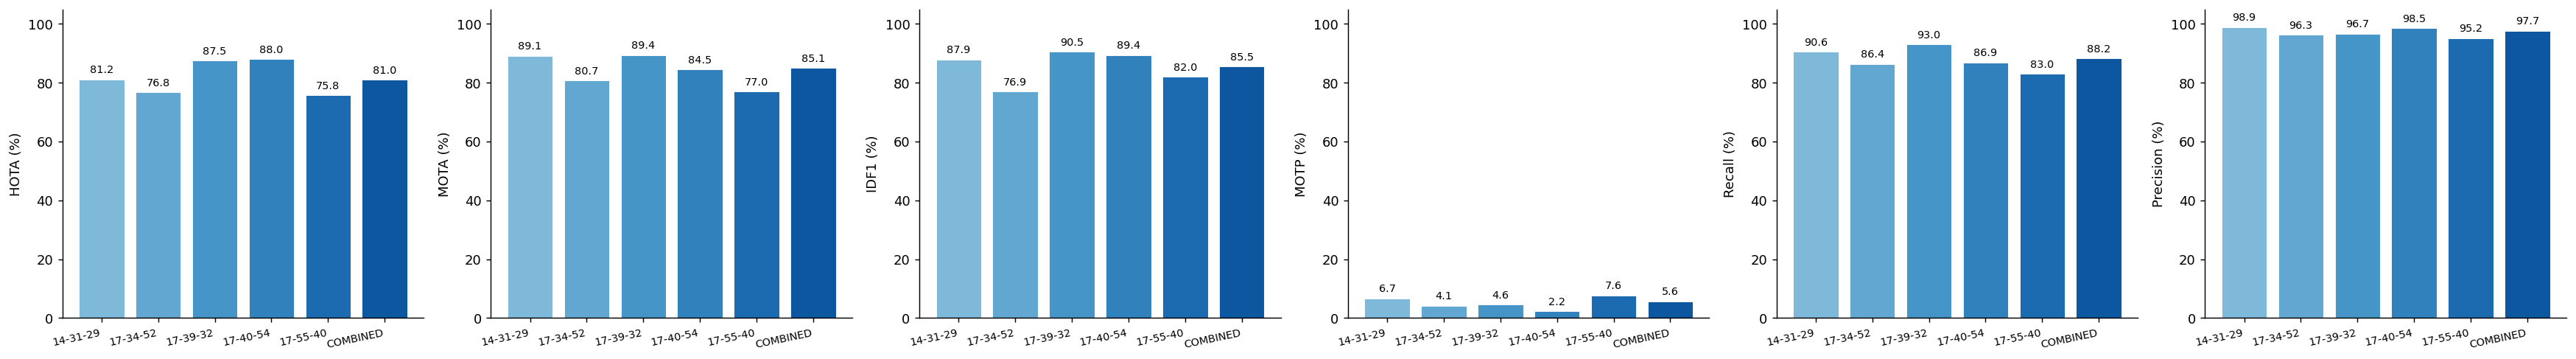

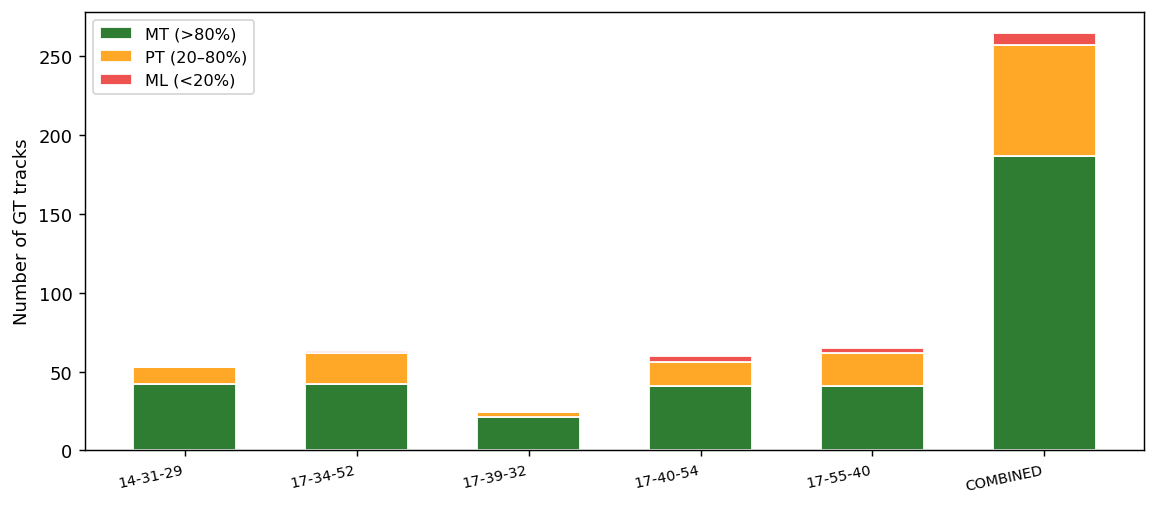


── BOTSORT combined (5 seq) ──
HOTA=82.8%  MOTA=85.9%  IDF1=87.7%  IDSW=75


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,83.0%,77.6%,92.8%,89.7%,89.2%,6.6%,91.0%,98.9%,51,449,12,42,0,53
1,17-34-52,80.2%,76.4%,84.6%,80.6%,83.5%,4.6%,86.3%,95.8%,67,245,34,43,1,63
2,17-39-32,89.9%,82.9%,99.2%,90.4%,94.8%,4.7%,93.8%,96.7%,16,31,1,22,0,24
3,17-40-54,89.1%,82.5%,96.4%,85.3%,90.8%,2.3%,87.3%,98.6%,20,202,13,42,4,60
4,17-55-40,76.5%,69.2%,87.2%,79.3%,82.8%,7.5%,83.9%,95.8%,61,269,15,42,2,65
5,COMBINED,82.8%,76.7%,91.4%,85.9%,87.7%,5.7%,88.6%,97.7%,215,1196,75,191,7,265


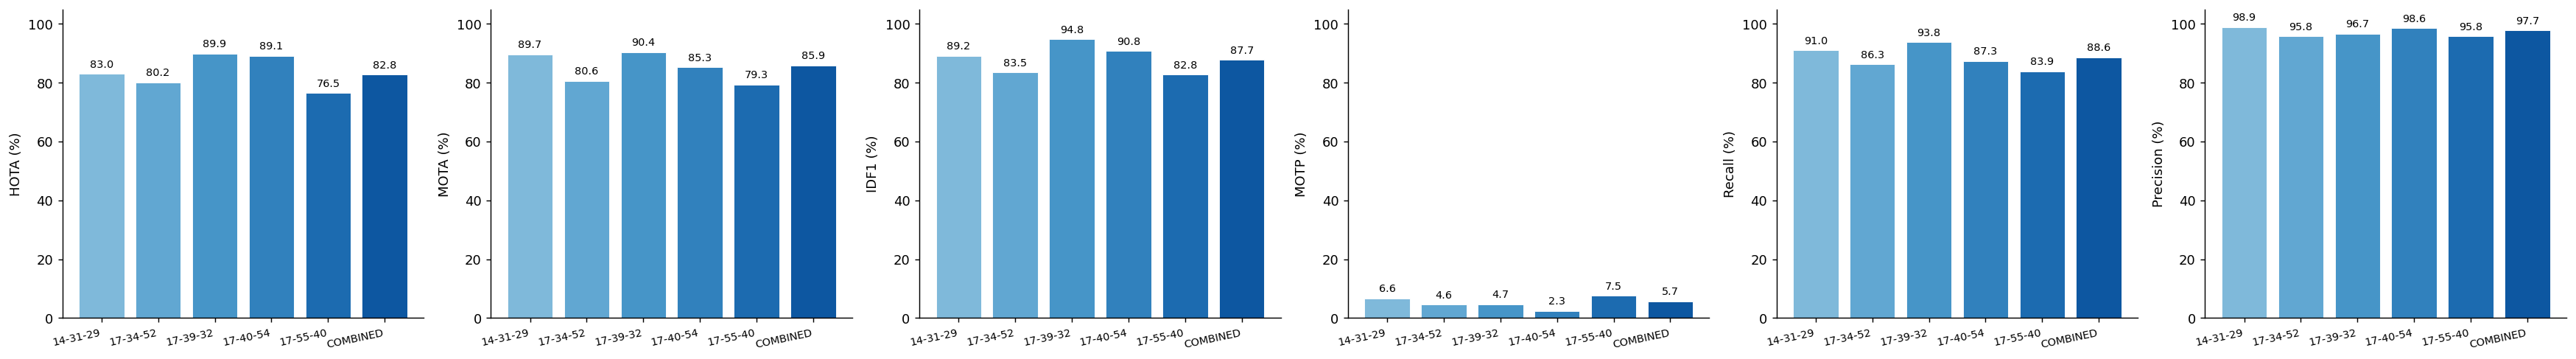

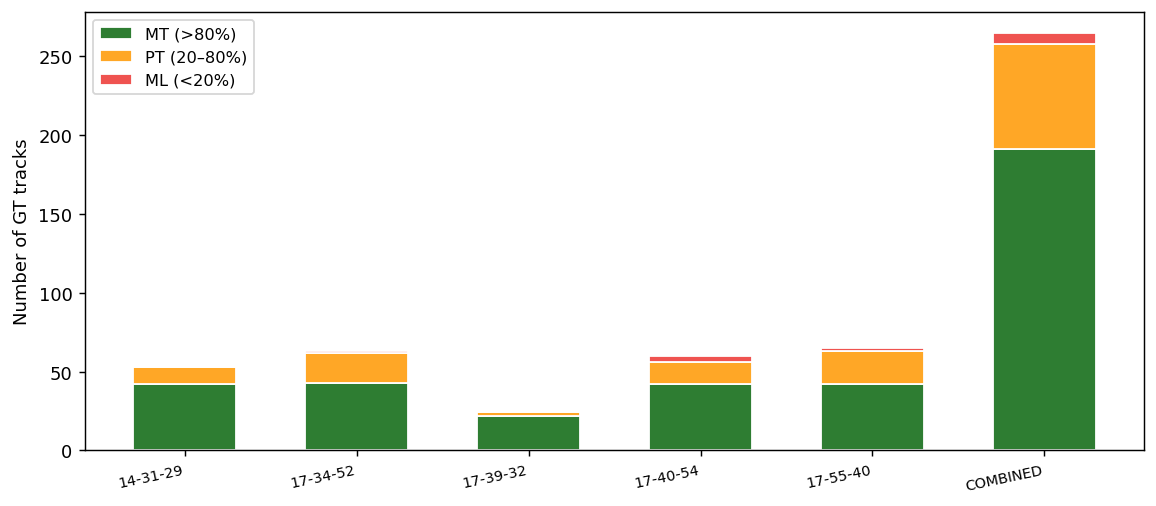

In [12]:
_OFF = 10_000

for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    results   = results_by_tracker[tracker]
    pred_dfs  = pred_by_tracker[tracker]

    gt_combined = pd.concat(
        [gt_dfs[s].assign(frame_norm=gt_dfs[s]["frame_norm"] + i * _OFF,
                          track_id  =gt_dfs[s]["track_id"]   + i * _OFF)
         for i, s in enumerate(SEQUENCES)], ignore_index=True)
    pred_combined = pd.concat(
        [pred_dfs[s].assign(frame_norm=pred_dfs[s]["frame_norm"] + i * _OFF,
                            track_id  =pred_dfs[s]["track_id"]   + i * _OFF)
         for i, s in enumerate(SEQUENCES)], ignore_index=True)

    _, summ_comb = compute_metrics(gt_combined, pred_combined, iou_threshold=IOU_MATCH)
    hota_comb    = compute_hota(gt_combined, pred_combined)
    for k, v in hota_comb.items():
        summ_comb[k] = v

    print(f"\n── {tracker.upper()} combined ({len(SEQUENCES)} seq) ──")
    print(f"HOTA={hota_comb['hota']*100:.1f}%  "
          f"MOTA={float(summ_comb['mota'].iloc[0])*100:.1f}%  "
          f"IDF1={float(summ_comb['idf1'].iloc[0])*100:.1f}%  "
          f"IDSW={int(summ_comb['num_switches'].iloc[0])}")

    results_all = dict(results) | {"COMBINED": summ_comb}
    display(build_summary_table(results_all))

    fig = plot_metrics_bar(
        results_all,
        metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
        title="",
    )
    clean_fig(fig)
    plt.tight_layout()
    plt.show()

    _seq_all = list(results_all.keys())
    _mt = [int(results_all[s]["mostly_tracked"].iloc[0])    for s in _seq_all]
    _pt = [int(results_all[s]["partially_tracked"].iloc[0]) for s in _seq_all]
    _ml = [int(results_all[s]["mostly_lost"].iloc[0])       for s in _seq_all]

    x = np.arange(len(_seq_all))
    fig, ax = plt.subplots(figsize=(max(7, len(_seq_all) * 1.5), 4))
    w = 0.6
    ax.bar(x, _mt, width=w, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
    ax.bar(x, _pt, width=w, bottom=_mt, label="PT (20–80%)", color="#FFA726", edgecolor="white")
    ax.bar(x, _ml, width=w, bottom=[m + p for m, p in zip(_mt, _pt)],
           label="ML (<20%)", color="#EF5350", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([s[-8:] for s in _seq_all], rotation=12, ha="right", fontsize=8)
    ax.set_ylabel("Number of GT tracks")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## V  GT vs Inference — auto-selected examples
Change `CMP_TRACKER`, `COMPARE_SEQ` to explore.

Sequence : 2024-08-20_14-31-29   Tracker : bytetrack
Searching for best FP / FN / TP example frames ...

───────────────────────────────────────────────────────
  TP example  |  seq 14-31-29  frame 1351  [bytetrack]
  TP=25  FP=0  FN=0  GT boxes=25  Pred boxes=25
  Green = GT    Red = Inference  Orange circle = FP
───────────────────────────────────────────────────────


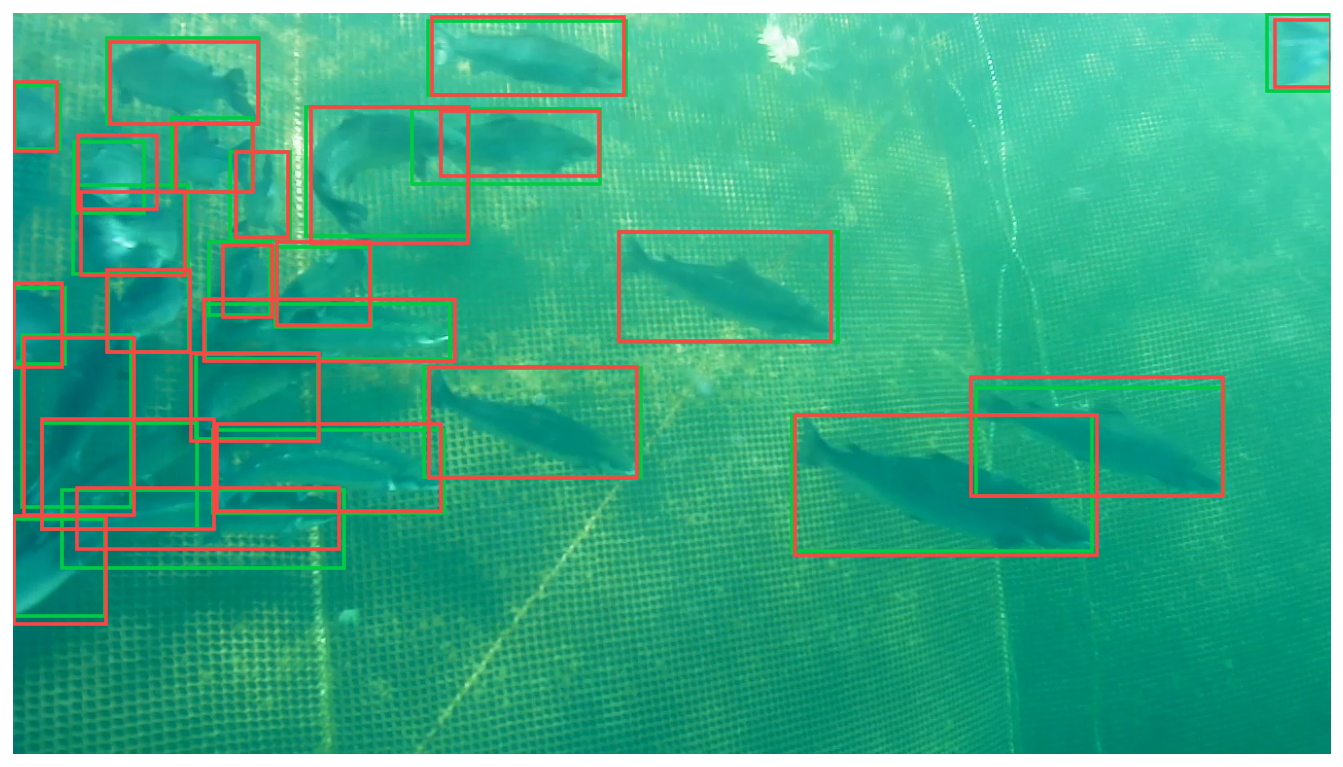


───────────────────────────────────────────────────────
  FN example  |  seq 14-31-29  frame 1314  [bytetrack]
  TP=13  FP=0  FN=8  GT boxes=21  Pred boxes=13
  Green = GT    Red = Inference  Orange circle = FP
───────────────────────────────────────────────────────


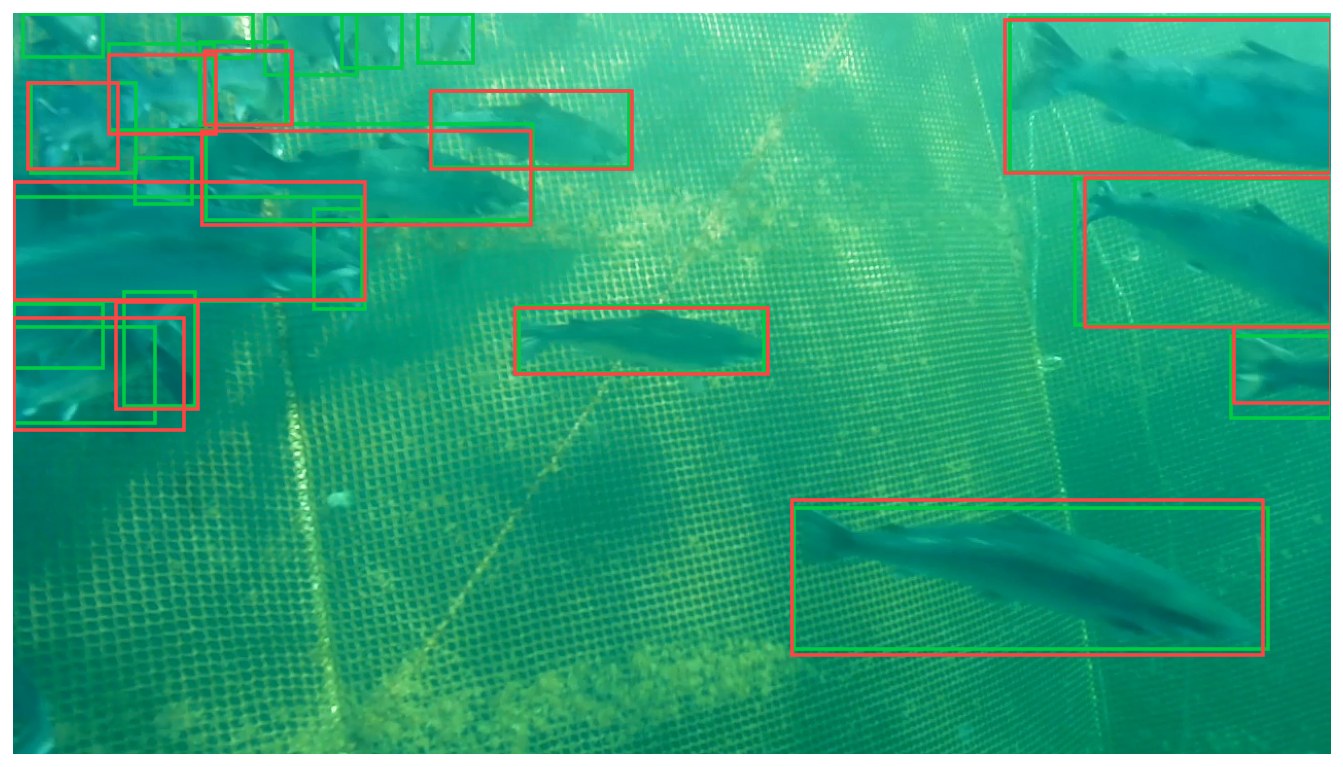


───────────────────────────────────────────────────────
  FP example  |  seq 14-31-29  frame 1357  [bytetrack]
  TP=21  FP=3  FN=3  GT boxes=24  Pred boxes=24
  Green = GT    Red = Inference  Orange circle = FP
───────────────────────────────────────────────────────


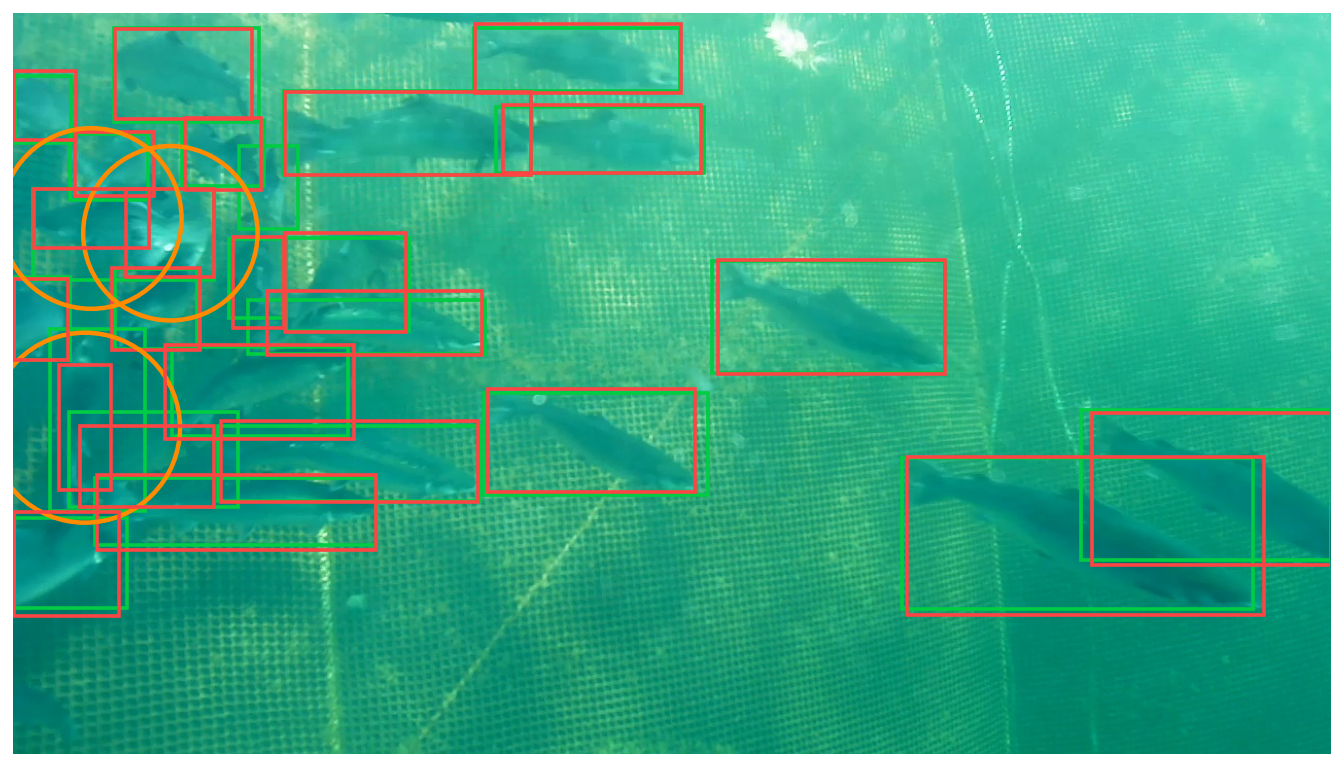

In [13]:
def _frame_match(gt_df_f, pred_df_f, iou_thresh=0.5):
    """Match GT and pred boxes for one frame via greedy IoU.
    Returns (n_tp, n_fp, n_fn, matched_gt_set, matched_pred_set)."""
    gt_arr   = gt_df_f[["x","y","w","h"]].values if len(gt_df_f) > 0 else np.empty((0,4))
    pred_arr = pred_df_f[["x","y","w","h"]].values if len(pred_df_f) > 0 else np.empty((0,4))
    n_gt, n_pred = len(gt_arr), len(pred_arr)
    if n_gt == 0 and n_pred == 0:
        return 0, 0, 0, set(), set()
    if n_gt == 0:
        return 0, n_pred, 0, set(), set(range(n_pred))
    if n_pred == 0:
        return 0, 0, n_gt, set(), set()
    iou   = _iou_matrix_xywh(gt_arr, pred_arr)
    pairs = sorted([(iou[i,j], i, j) for i in range(n_gt) for j in range(n_pred)], reverse=True)
    mg, mp = set(), set()
    for score, i, j in pairs:
        if score < iou_thresh: break
        if i in mg or j in mp: continue
        mg.add(i); mp.add(j)
    return len(mg), n_pred - len(mp), n_gt - len(mg), mg, mp


def _find_examples(gt_df, pred_df, fn_to_img, iou_thresh=0.5):
    """Scan all frames; return best frame_norm for FP-heavy, FN-heavy, TP-clean."""
    frames = sorted(set(gt_df["frame_norm"].unique()) | set(pred_df["frame_norm"].unique()))
    best = {"fp": (0, None), "fn": (0, None), "tp": (0, None)}
    for fn in frames:
        if fn not in fn_to_img:
            continue
        gt_f   = gt_df[gt_df["frame_norm"] == fn]
        pred_f = pred_df[pred_df["frame_norm"] == fn]
        n_tp, n_fp, n_fn, _, _ = _frame_match(gt_f, pred_f, iou_thresh)
        # FP focus: maximise FPs with at least some GT context
        if n_fp > best["fp"][0] and n_tp + n_fn >= 1:
            best["fp"] = (n_fp, fn)
        # FN focus: maximise FNs with at least some predictions present
        if n_fn > best["fn"][0] and n_tp + n_fp >= 1:
            best["fn"] = (n_fn, fn)
        # TP focus: most TPs with fewest errors and at least 3 boxes
        tp_score = n_tp - n_fp - n_fn
        if tp_score > best["tp"][0] and n_tp >= 3:
            best["tp"] = (tp_score, fn)
    return best["fp"][1], best["fn"][1], best["tp"][1]


FP_CIRCLE_COLOR = "#FF8C00"   # orange ring around false positives

def _show_frame(img_path, gt_f, pred_f, iou_thresh, gt_color, pred_color, label,
                zoom=None, overlay_boxes=None):
    """
    zoom         : ((x1, x2), (y1, y2)) pixel crop — None = full image
    overlay_boxes: list of (DataFrame, color, linestyle) drawn on top of everything
    """
    n_tp, n_fp, n_fn, _, matched_pred = _frame_match(gt_f, pred_f, iou_thresh)
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"  TP={n_tp}  FP={n_fp}  FN={n_fn}  "
          f"GT boxes={len(gt_f)}  Pred boxes={len(pred_f)}")
    extra = "  Orange circle = FP"
    if overlay_boxes:
        extra += "    Blue dashed = net GT"
    print(f"  Green = GT    Red = Inference{extra}")
    print(f"{'─'*55}")
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.imshow(img)
    for _, row in gt_f.iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=gt_color, facecolor="none"))
    for i, (_, row) in enumerate(pred_f.iterrows()):
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=pred_color, facecolor="none"))
        if i not in matched_pred:
            cx = row.x + row.w / 2
            cy = row.y + row.h / 2
            r  = np.sqrt((row.w / 2) ** 2 + (row.h / 2) ** 2) * 1.4
            ax.add_patch(plt.Circle((cx, cy), r, fill=False,
                                    edgecolor=FP_CIRCLE_COLOR, linewidth=2.5))
    if overlay_boxes:
        for df_ov, ov_color, ov_ls in overlay_boxes:
            for _, row in df_ov.iterrows():
                ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                           linewidth=2, edgecolor=ov_color,
                                           facecolor="none", linestyle=ov_ls))
    if zoom is not None:
        (x1, x2), (y1, y2) = zoom   # y1 = top pixel, y2 = bottom pixel
        ax.set_xlim(x1, x2)
        ax.set_ylim(y2, y1)          # inverted: larger y value = bottom of image
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# ── Config ────────────────────────────────────────────────────────────────────
CMP_TRACKER = TRACKERS[0]   # "bytetrack" or "botsort"
COMPARE_SEQ = SEQUENCES[0]  # any sequence from SEQUENCES
IOU_THRESH  = 0.5
GT_COLOR    = "#00CC44"
PRED_COLOR  = "#FF4444"

idir_c      = img_dir_for(VISION_ROOT / COMPARE_SEQ, "vision")
fn_to_img_c = {i + 1: p for i, p in enumerate(collect_images(idir_c))}
gt_c        = gt_dfs[COMPARE_SEQ]
pred_c      = pred_by_tracker[CMP_TRACKER][COMPARE_SEQ]

print(f"Sequence : {COMPARE_SEQ}   Tracker : {CMP_TRACKER}")
print("Searching for best FP / FN / TP example frames ...")
fp_frame, fn_frame, tp_frame = _find_examples(gt_c, pred_c, fn_to_img_c, IOU_THRESH)

for label, fn in [("TP example", tp_frame), ("FN example", fn_frame), ("FP example", fp_frame)]:
    if fn is None:
        print(f"  {label}: no suitable frame found")
        continue
    gt_f   = gt_c[gt_c["frame_norm"]   == fn]
    pred_f = pred_c[pred_c["frame_norm"] == fn]
    _show_frame(fn_to_img_c[fn], gt_f, pred_f, IOU_THRESH, GT_COLOR, PRED_COLOR,
                f"{label}  |  seq {COMPARE_SEQ[-8:]}  frame {fn}  [{CMP_TRACKER}]")


## W  GT vs Inference — manual frame browser
Set `FRAME_NR` and re-run the cell.


───────────────────────────────────────────────────────
  seq 14-31-29  frame 100  [bytetrack]
  TP=0  FP=0  FN=0  GT boxes=0  Pred boxes=0
  Green = GT    Red = Inference  Orange circle = FP
───────────────────────────────────────────────────────


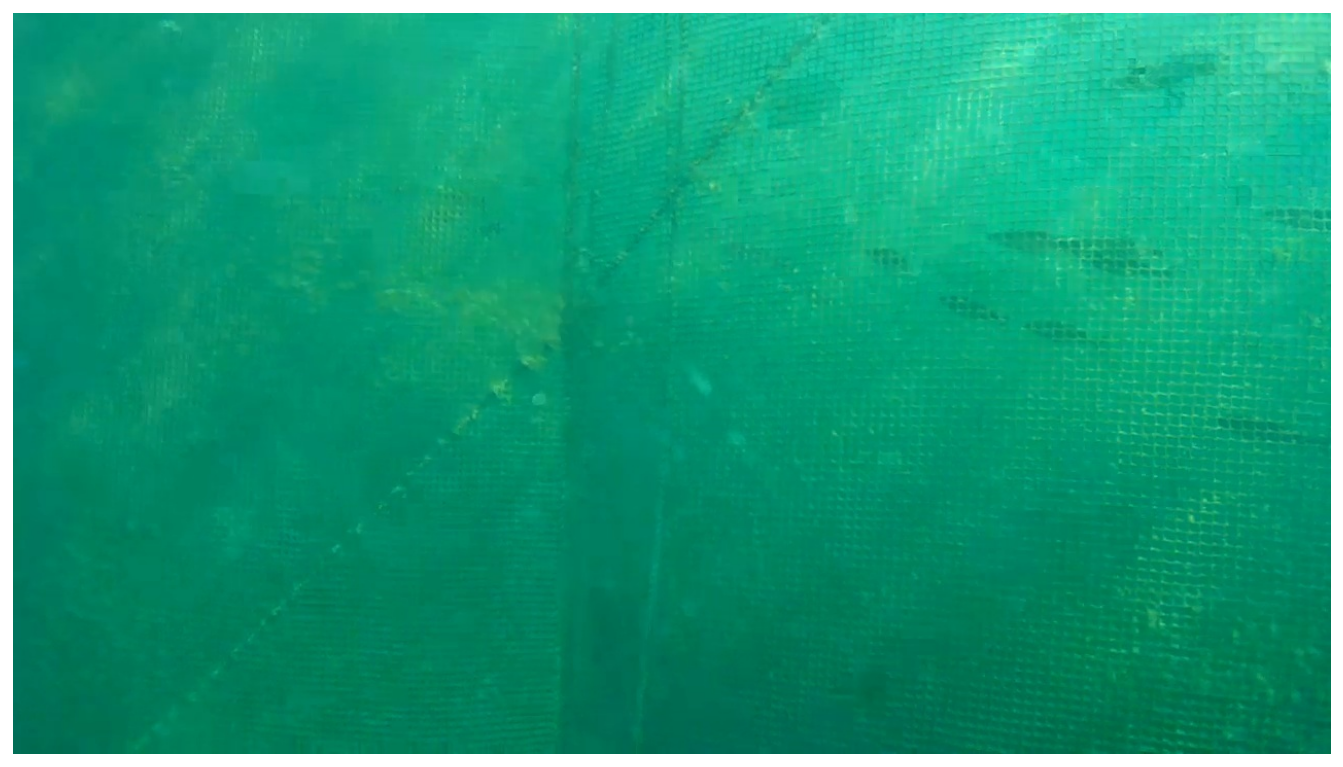

In [14]:
# ── Set these, then re-run the cell ──────────────────────────────────────────
CMP_TRACKER = TRACKERS[0]    # "bytetrack" or "botsort"
COMPARE_SEQ = SEQUENCES[0]   # any sequence from SEQUENCES
FRAME_NR    = 100             # frame number to inspect (1-indexed)
IOU_THRESH  = 0.5
GT_COLOR    = "#00CC44"
PRED_COLOR  = "#FF4444"

idir_c      = img_dir_for(VISION_ROOT / COMPARE_SEQ, "vision")
fn_to_img_c = {i + 1: p for i, p in enumerate(collect_images(idir_c))}
gt_c        = gt_dfs[COMPARE_SEQ]
pred_c      = pred_by_tracker[CMP_TRACKER][COMPARE_SEQ]

if FRAME_NR not in fn_to_img_c:
    print(f"Frame {FRAME_NR} not in sequence (valid range: 1–{len(fn_to_img_c)})")
else:
    gt_f   = gt_c[gt_c["frame_norm"]   == FRAME_NR]
    pred_f = pred_c[pred_c["frame_norm"] == FRAME_NR]
    _show_frame(fn_to_img_c[FRAME_NR], gt_f, pred_f, IOU_THRESH, GT_COLOR, PRED_COLOR,
                f"seq {COMPARE_SEQ[-8:]}  frame {FRAME_NR}  [{CMP_TRACKER}]")
